### Pesudo Radar Data 
In this notebook the different pseudo radar generators and the discritization will be shown. 

In [1]:
# std lib imports


# 3 party import
import numpy as np
import torch
import matplotlib.pyplot as plt

# projekt imports
from RadarDataGen.Data_Generator.pseudo_radar_points import pseudo_radar_points
from RadarDataGen.Discretizer.radar_discretizer import RadarDiscretizer

In [2]:
discretizer = RadarDiscretizer(64, -1, 1, -1, 1, 1.0)
axis_limits = [-1, 1, -1, 1]

### Pseudo radar data with 2d lines + one random dim and some clutter points
This function generates synthetic 2D radar data. Points are sampled along random straight lines, simulating signal reflections, and additional clutter points are uniformly scattered to represent noise. Each point includes a third value used for coloring with is random (because we only sample 2d random lines).

In [3]:
lambda_lines_2d=10
lambda_points_per_line_2d=20
lambda_clutter=50

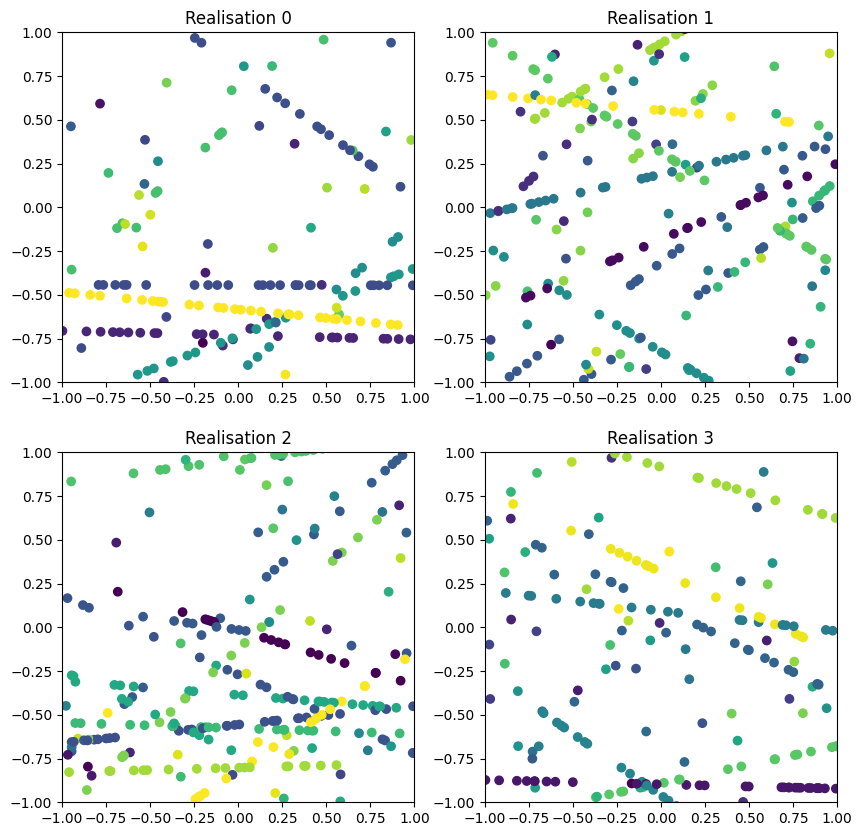

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

for i in range(4):
    row, col = divmod(i, 2)
    points = pseudo_radar_points(lambda_lines_2d=lambda_lines_2d, lambda_points_line_2d=lambda_points_per_line_2d, lambda_clutter=lambda_clutter)
    ax[row][col].scatter(*points[:, :2].T, c=points[:, 2])
    ax[row][col].axis(axis_limits)
    ax[row][col].set_title(f'Realisation {i}')


### Pseudo radar data with 3d lines some clutter points
This function generates synthetic 3D radar data. Points are sampled along random straight lines in 3D space, and additional clutter points are uniformly scattered to simulate noise. Each point includes three coordinates (X, Y, Z), and the Z value is used for coloring in the 2D plot.

In [5]:
lambda_lines_3d = 10
lambda_points_per_line_3d = 20
lambda_clutter_3d = 20

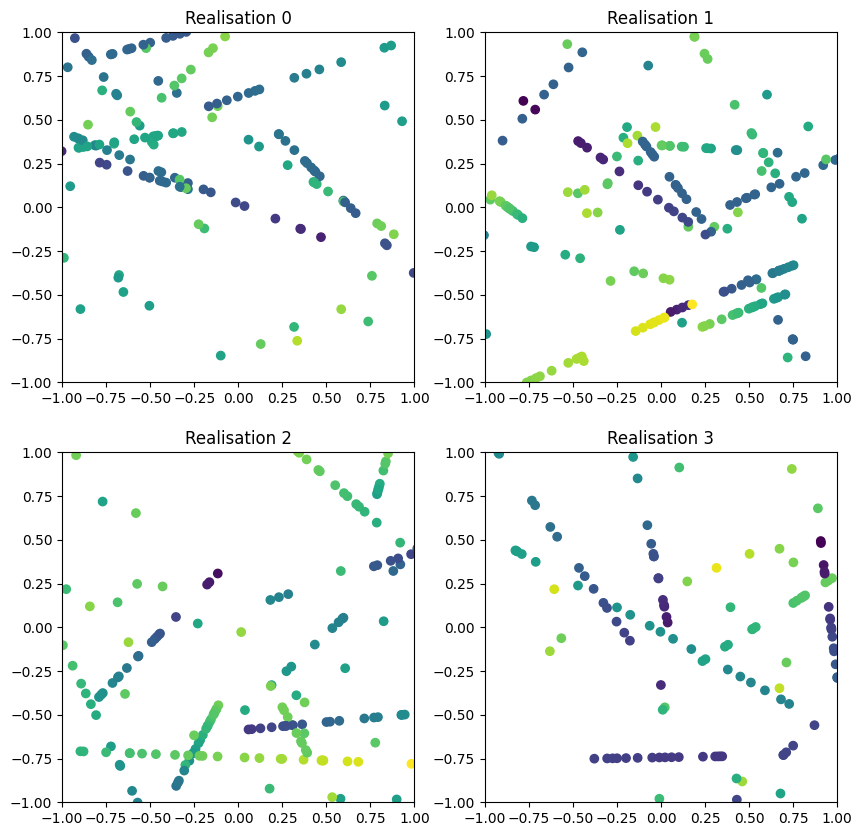

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
axis_limits = [-1, 1, -1, 1]

for i in range(4):
    row, col = divmod(i, 2)
    points = pseudo_radar_points(lambda_lines_3d = lambda_lines_3d, lambda_points_line_3d = lambda_points_per_line_3d, lambda_clutter = lambda_clutter_3d)
    ax[row][col].scatter(*points[:, :2].T, c=points[:, 2])
    ax[row][col].axis(axis_limits)
    ax[row][col].set_title(f'Realisation {i}')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-14.568071..21.886547].


Reconstruction error: 0.000000


Text(0.5, 1.0, 'Reconstructed')

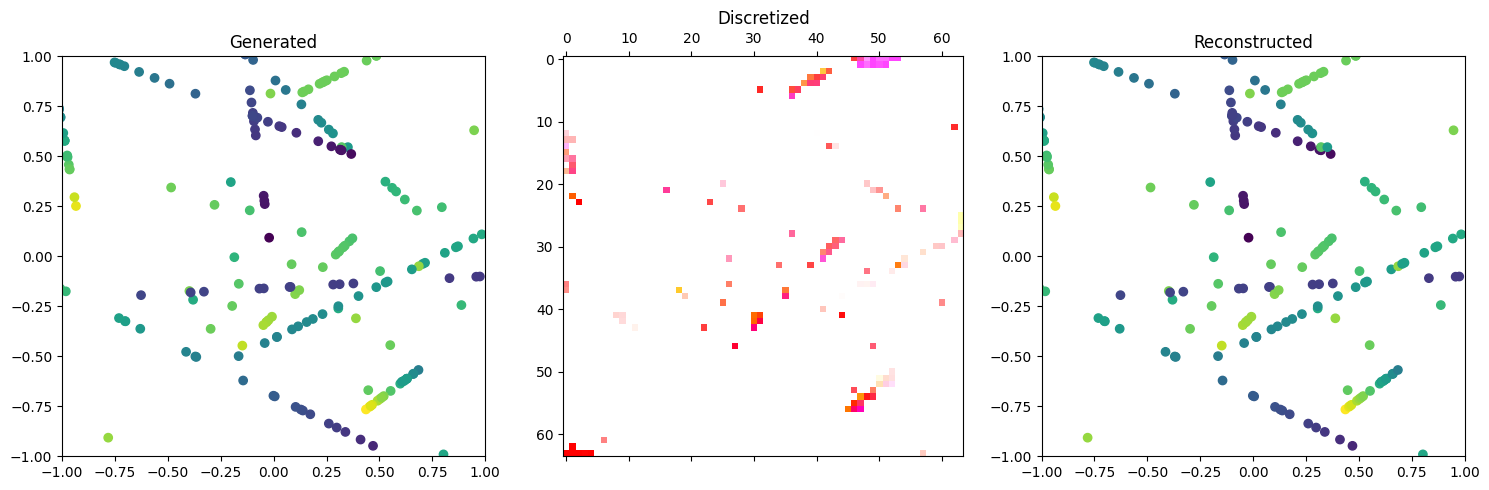

In [7]:
points = pseudo_radar_points(lambda_lines_3d = lambda_lines_3d, lambda_points_line_3d = lambda_points_per_line_3d, lambda_clutter = lambda_clutter_3d)
grid = discretizer.points_to_grid(points)
points_from_grid = discretizer.grid_to_points(grid.swapaxes(0, 2).swapaxes(1, 2))

error = np.linalg.norm(points[np.lexsort(points.T)] - points_from_grid[np.lexsort(points_from_grid.T)])
print(f'Reconstruction error: {error:.6f}')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)

axis_limits = [-1, 1, -1, 1]
ax1.scatter(*points[:, :2].T, c=points[:, 2])
ax1.axis(axis_limits)
ax1.set_title('Generated')

image = discretizer.grid_to_image(grid, swap_xy=True, invert_rows=True, invert_columns=False)
ax2.matshow(image)
ax2.set_title('Discretized')

ax3.scatter(*points_from_grid[:, :2].T, c=points_from_grid[:, 2])
ax3.axis(axis_limits)
ax3.set_title('Reconstructed')

In [8]:
print(np.sum(grid[0, ...]))

-9.889078


### Pseudo Radar Data with random rectangels in R2

In [9]:
lambda_rectangle = 4
lambda_points_rectangle = 50

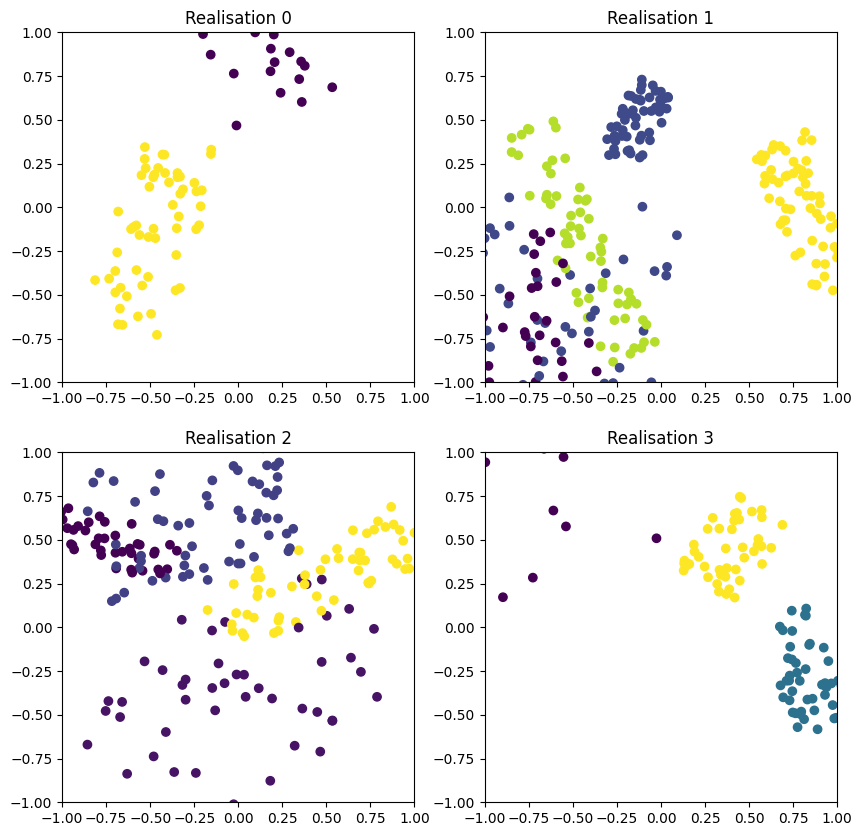

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
axis_limits = [-1, 1, -1, 1]

for i in range(4):
    row, col = divmod(i, 2)
    points = pseudo_radar_points(lambda_rectangle_2d = lambda_rectangle, lambda_points_rectangle_2d = lambda_points_rectangle)
    ax[row][col].scatter(*points[:, :2].T, c=points[:, 2])
    ax[row][col].axis(axis_limits)
    ax[row][col].set_title(f'Realisation {i}')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-43.017773..21.806581].


Reconstruction error: 0.000000


Text(0.5, 1.0, 'Reconstructed')

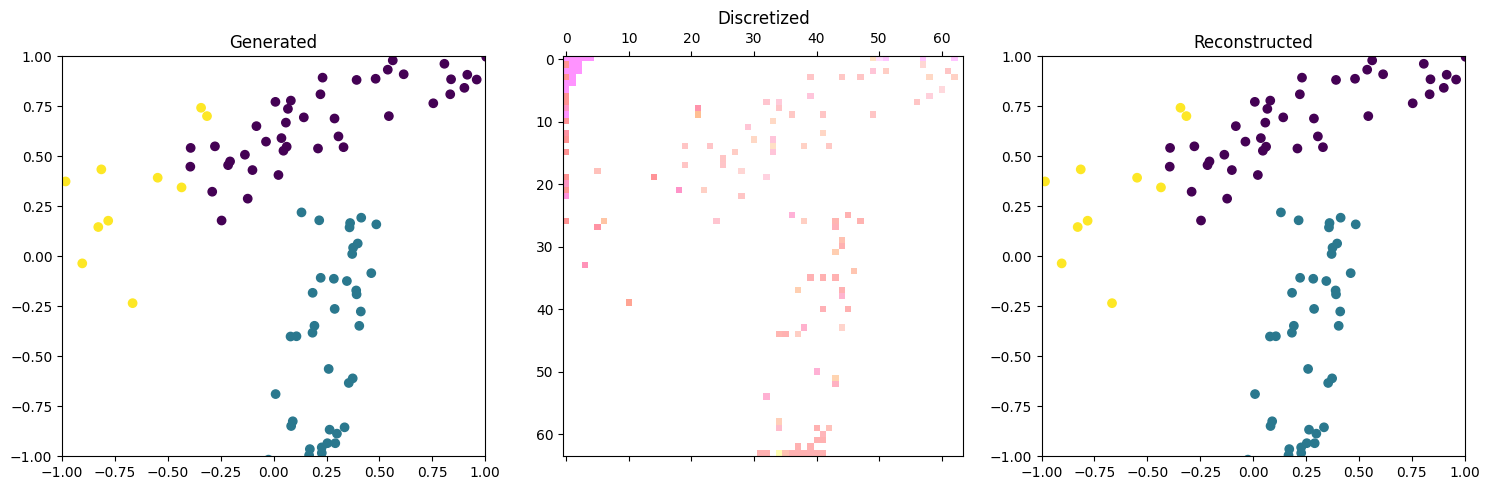

In [11]:
points = pseudo_radar_points(lambda_rectangle_2d = lambda_rectangle, lambda_points_rectangle_2d = lambda_points_rectangle)
grid = discretizer.points_to_grid(points)
points_from_grid = discretizer.grid_to_points(grid.swapaxes(0, 2).swapaxes(1, 2))

error = np.linalg.norm(points[np.lexsort(points.T)] - points_from_grid[np.lexsort(points_from_grid.T)])
print(f'Reconstruction error: {error:.6f}')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)

axis_limits = [-1, 1, -1, 1]
ax1.scatter(*points[:, :2].T, c=points[:, 2])
ax1.axis(axis_limits)
ax1.set_title('Generated')

image = discretizer.grid_to_image(grid, swap_xy=True, invert_rows=True, invert_columns=False)
ax2.matshow(image)
ax2.set_title('Discretized')

ax3.scatter(*points_from_grid[:, :2].T, c=points_from_grid[:, 2])
ax3.axis(axis_limits)
ax3.set_title('Reconstructed')

### Pseudo Radar Data with random rectangels with no filling points  in R2

In [12]:
lambda_rect_outline_2d = 4
lambda_points_rect_outline_2d = 50
lambda_clutter = 40

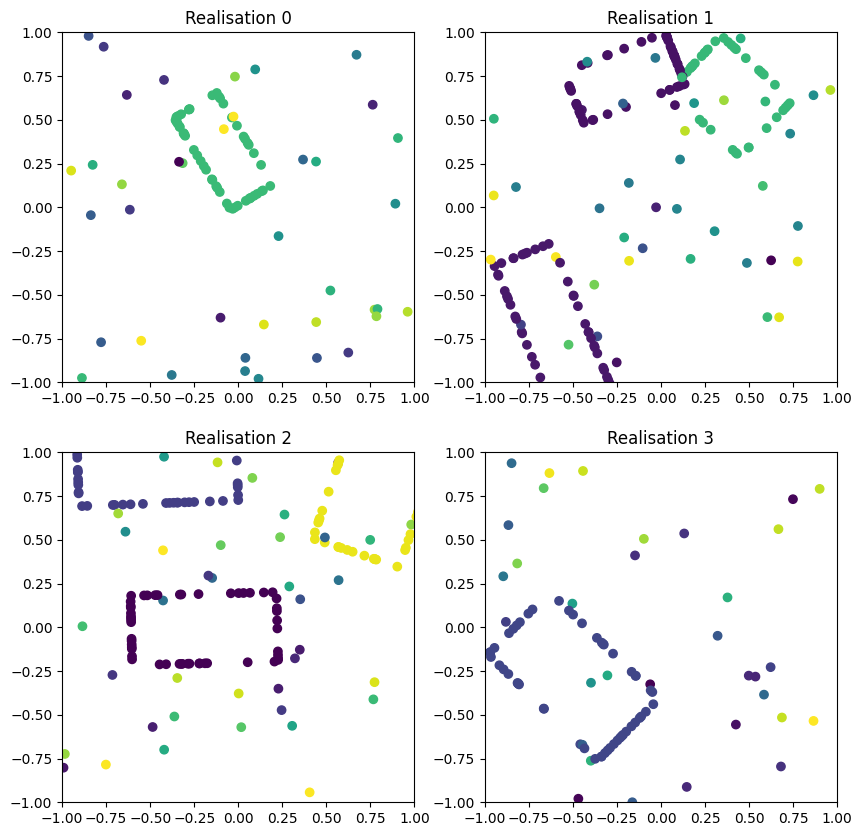

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
axis_limits = [-1, 1, -1, 1]

for i in range(4):
    row, col = divmod(i, 2)
    points = pseudo_radar_points(lambda_rect_outline_2d = lambda_rect_outline_2d, lambda_points_rect_outline_2d = lambda_points_rect_outline_2d, lambda_clutter=lambda_clutter)
    ax[row][col].scatter(*points[:, :2].T, c=points[:, 2])
    ax[row][col].axis(axis_limits)
    ax[row][col].set_title(f'Realisation {i}')

### Pseudo Radar Data with random rectangels in R3 

In [14]:
lambda_rectangle = 3
lambda_points_rectangle = 40

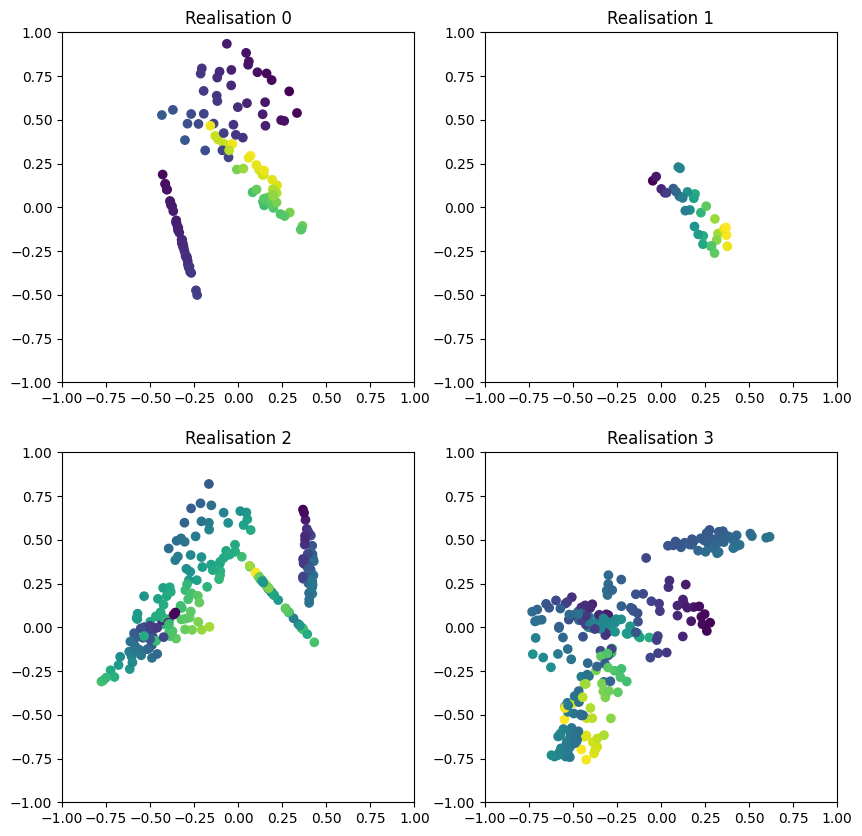

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
axis_limits = [-1, 1, -1, 1]

for i in range(4):
    row, col = divmod(i, 2)
    points = pseudo_radar_points(lambda_rectangle_3d = lambda_rectangle, lambda_points_rectangle_3d = lambda_points_rectangle)
    ax[row][col].scatter(*points[:, :2].T, c=points[:, 2])
    ax[row][col].axis(axis_limits)
    ax[row][col].set_title(f'Realisation {i}')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7551411..1.4042478].


Reconstruction error: 0.000000


Text(0.5, 1.0, 'Reconstructed')

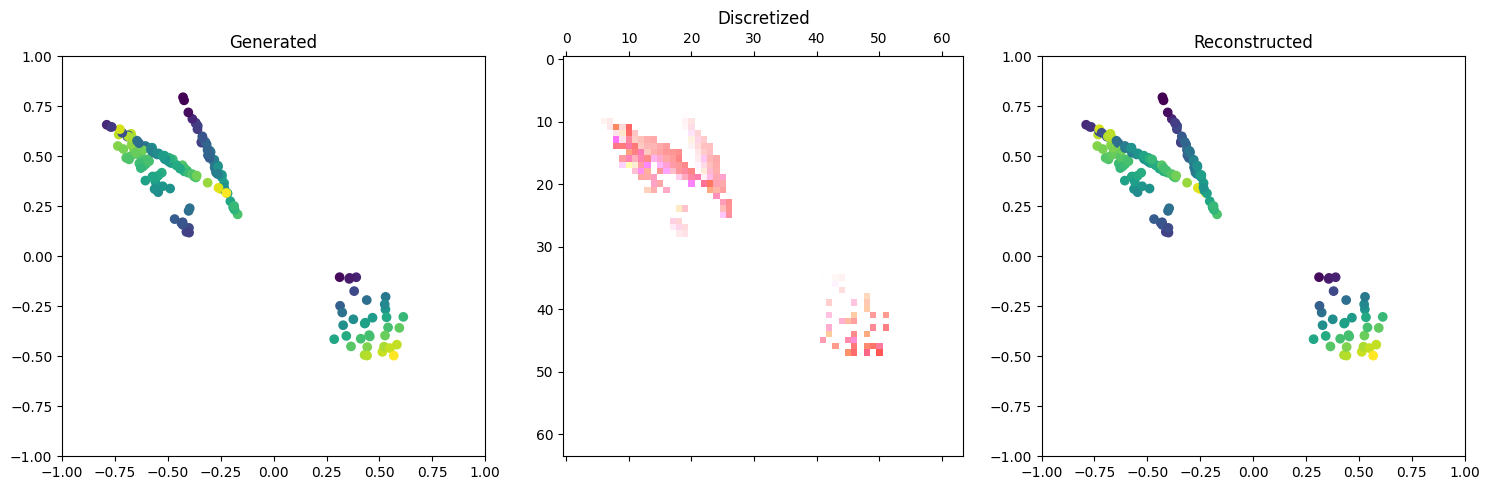

In [16]:
points = pseudo_radar_points(lambda_rectangle_3d = lambda_rectangle, lambda_points_rectangle_3d = lambda_points_rectangle)
grid = discretizer.points_to_grid(points)
points_from_grid = discretizer.grid_to_points(grid.swapaxes(0, 2).swapaxes(1, 2))

error = np.linalg.norm(points[np.lexsort(points.T)] - points_from_grid[np.lexsort(points_from_grid.T)])
print(f'Reconstruction error: {error:.6f}')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)

axis_limits = [-1, 1, -1, 1]
ax1.scatter(*points[:, :2].T, c=points[:, 2])
ax1.axis(axis_limits)
ax1.set_title('Generated')

image = discretizer.grid_to_image(grid, swap_xy=True, invert_rows=True, invert_columns=False)
ax2.matshow(image)
ax2.set_title('Discretized')

ax3.scatter(*points_from_grid[:, :2].T, c=points_from_grid[:, 2])
ax3.axis(axis_limits)
ax3.set_title('Reconstructed')

### Pseudo Radar Data with random circles in R2 

In [17]:
lambda_circles = 3
lambda_points_circles = 40

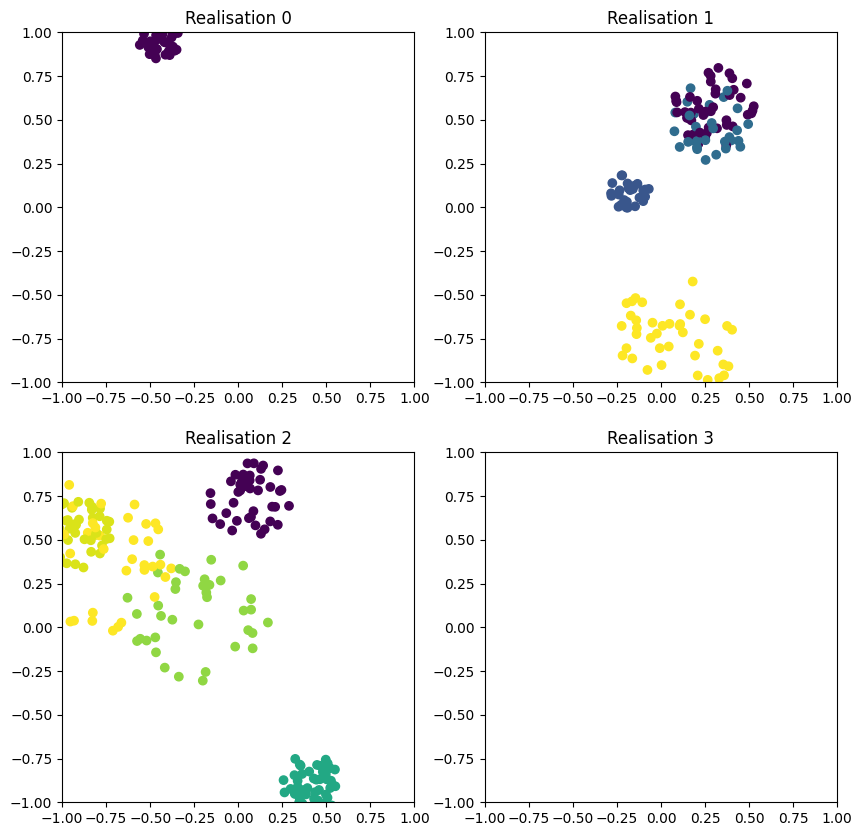

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
axis_limits = [-1, 1, -1, 1]

for i in range(4):
    row, col = divmod(i, 2)
    points = pseudo_radar_points(lambda_circle= lambda_circles, lambda_points_circle= lambda_points_circles)
    ax[row][col].scatter(*points[:, :2].T, c=points[:, 2])
    ax[row][col].axis(axis_limits)
    ax[row][col].set_title(f'Realisation {i}')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-10.162615..1.0].


Reconstruction error: 0.000000


Text(0.5, 1.0, 'Reconstructed')

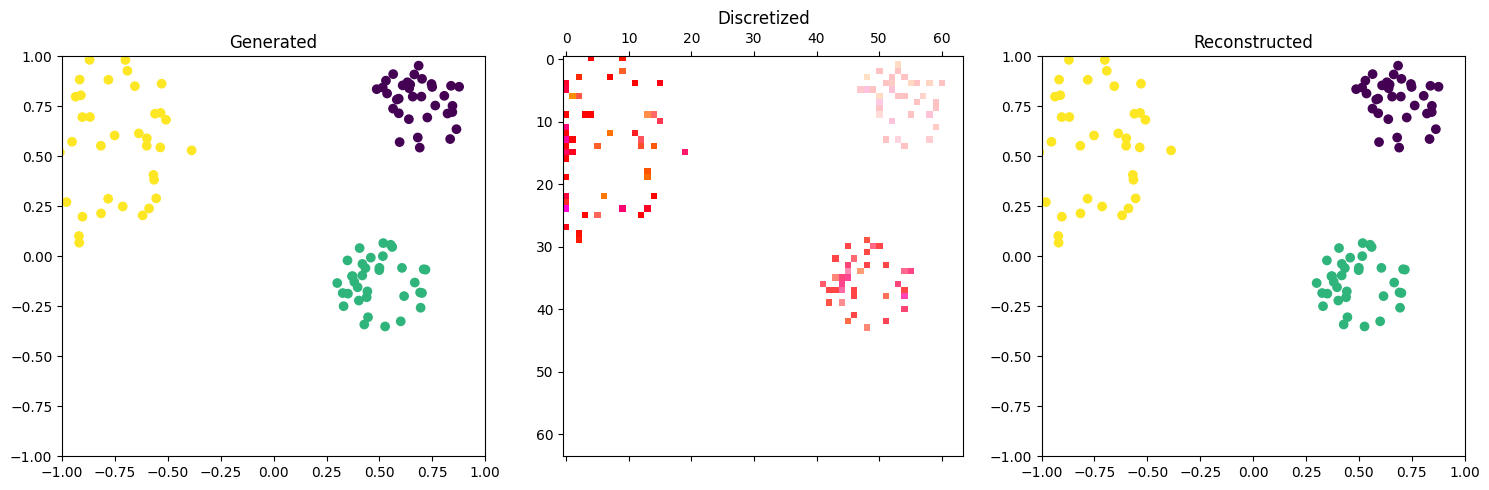

In [19]:
points = pseudo_radar_points(lambda_circle= lambda_circles, lambda_points_circle= lambda_points_circles)
grid = discretizer.points_to_grid(points)
points_from_grid = discretizer.grid_to_points(grid.swapaxes(0, 2).swapaxes(1, 2))

error = np.linalg.norm(points[np.lexsort(points.T)] - points_from_grid[np.lexsort(points_from_grid.T)])
print(f'Reconstruction error: {error:.6f}')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)

axis_limits = [-1, 1, -1, 1]
ax1.scatter(*points[:, :2].T, c=points[:, 2])
ax1.axis(axis_limits)
ax1.set_title('Generated')

image = discretizer.grid_to_image(grid, swap_xy=True, invert_rows=True, invert_columns=False)
ax2.matshow(image)
ax2.set_title('Discretized')

ax3.scatter(*points_from_grid[:, :2].T, c=points_from_grid[:, 2])
ax3.axis(axis_limits)
ax3.set_title('Reconstructed')

### All together 

In [20]:
lambda_lines_2d=4
lambda_points_per_line_2d=20

lambda_circles = 1
lambda_points_circles = 40

lambda_rect_outline_2d = 2
lambda_points_rect_outline_2d = 40

lambda_clutter = 40

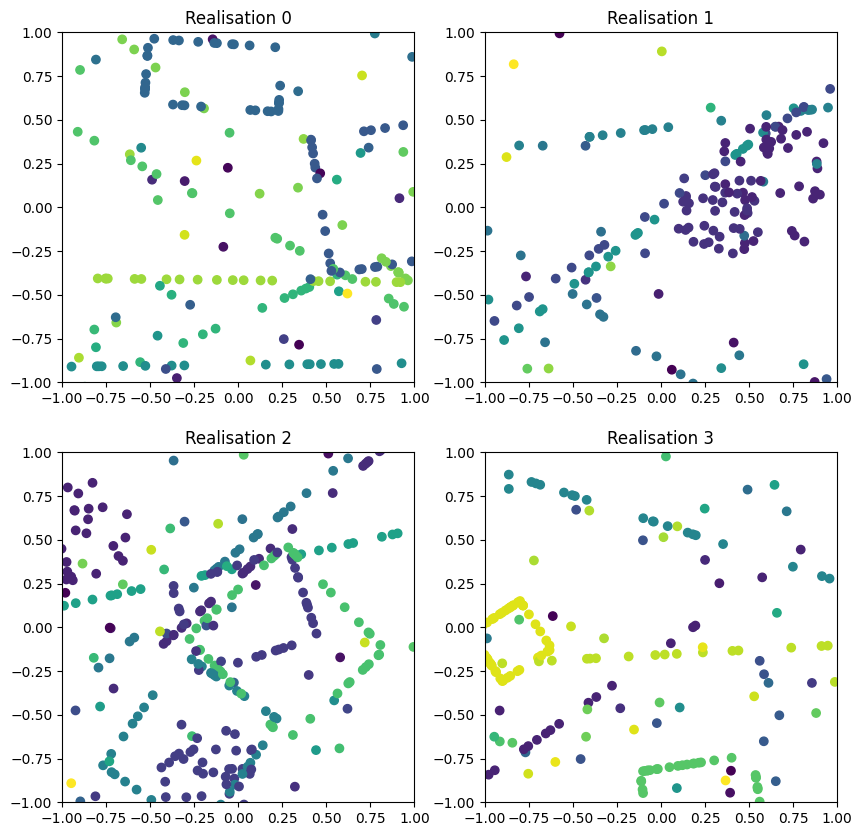

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
axis_limits = [-1, 1, -1, 1]

for i in range(4):
    row, col = divmod(i, 2)
    points = pseudo_radar_points(lambda_clutter=lambda_clutter, lambda_rect_outline_2d= lambda_rect_outline_2d, lambda_points_rect_outline_2d=lambda_points_rect_outline_2d, lambda_lines_2d= lambda_lines_2d, lambda_points_line_2d=lambda_points_per_line_2d, lambda_circle= lambda_circles, lambda_points_circle= lambda_points_circles)
    ax[row][col].scatter(*points[:, :2].T, c=points[:, 2])
    ax[row][col].axis(axis_limits)
    ax[row][col].set_title(f'Realisation {i}')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-10.940169..31.446665].


Reconstruction error: 0.000000


Text(0.5, 1.0, 'Reconstructed')

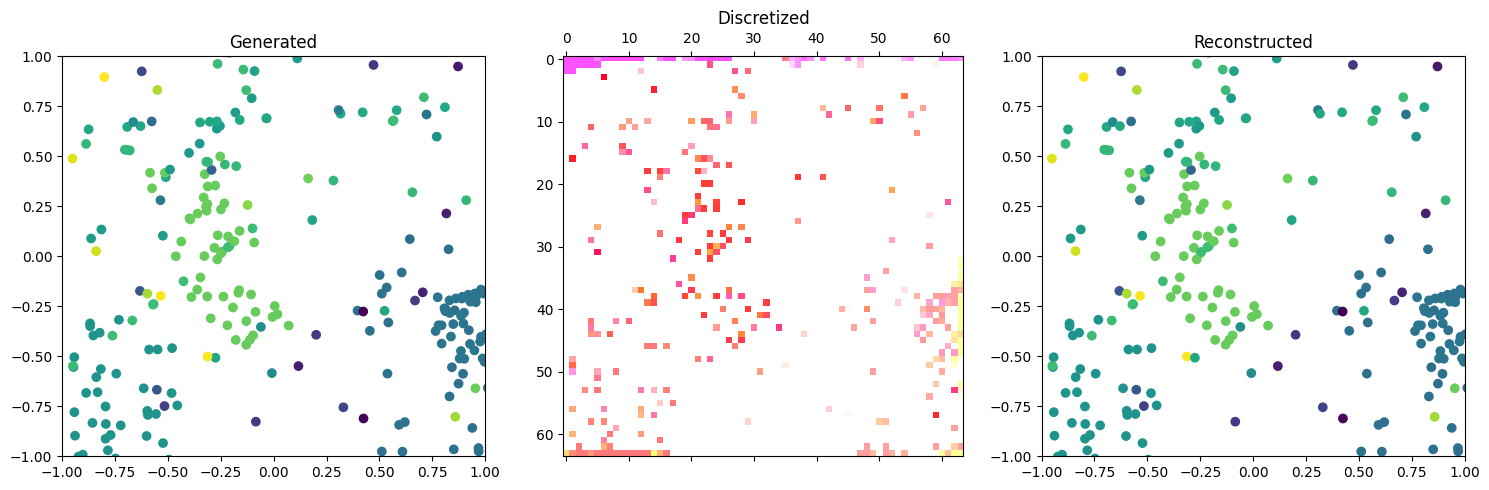

In [22]:
points = pseudo_radar_points(lambda_clutter=lambda_clutter, lambda_rectangle_2d= lambda_rectangle, lambda_points_rectangle_2d=lambda_points_rectangle, lambda_lines_2d= lambda_lines_2d, lambda_points_line_2d=lambda_points_per_line_2d, lambda_circle= lambda_circles, lambda_points_circle= lambda_points_circles)
grid = discretizer.points_to_grid(points)
points_from_grid = discretizer.grid_to_points(grid.swapaxes(0, 2).swapaxes(1, 2))

error = np.linalg.norm(points[np.lexsort(points.T)] - points_from_grid[np.lexsort(points_from_grid.T)])
print(f'Reconstruction error: {error:.6f}')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)

axis_limits = [-1, 1, -1, 1]
ax1.scatter(*points[:, :2].T, c=points[:, 2])
ax1.axis(axis_limits)
ax1.set_title('Generated')

image = discretizer.grid_to_image(grid, swap_xy=True, invert_rows=True, invert_columns=False)
ax2.matshow(image)
ax2.set_title('Discretized')

ax3.scatter(*points_from_grid[:, :2].T, c=points_from_grid[:, 2])
ax3.axis(axis_limits)
ax3.set_title('Reconstructed')